# Phase 4: DeepFM Architecture & Model Training (PyTorch)

## 1. Methodology: Independent Events, Splitting, and Cold-Start
In this phase, we construct a Custom PyTorch Deep Factorization Machine (DeepFM) to predict complex physical delivery delays.

**1. Data Splitting Strategy (Random Shuffle):**
Because the Silver data engineering phase successfully encapsulated all temporal and contextual memory (e.g., `prev_cod_amount`, `trip_progress_ratio`) into isolated vectors, each row acts as an independent physical event. Therefore, we utilize a random shuffle split (80/20) rather than a strict chronological split. This guarantees that both the training and testing sets contain identically distributed representations of rare physical events (such as heavy rain or unverified pins).

**2. Handling Unseen Data (The Cold Start Problem):**
In real-world logistics, new couriers and customers appear daily. To ensure the model remains robust on unseen IDs, we utilize **Embedding Dropout**.
By randomly masking specific `customer_id` or `driver_id` embeddings during training, the network is penalized for memorizing specific people. Instead, it is forced to shift its predictive weight to the **Macro Features**: dense physics (Rain, Distance) and categorical topologies (Location Type, Grid IDs).

In [1]:
# ==========================================
# 1. COLAB ENVIRONMENT SETUP
# ==========================================
# Quietly unzip the uploaded data into the Colab environment
!unzip -q lamigo_deepfm_data.zip -d ./

# Ensure joblib is available (we will need it later to load encoders)
!pip install -q joblib

# Standard Data Science & Deep Learning imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import joblib
import os
import warnings

# Keep notebook output clean for the thesis
warnings.filterwarnings('ignore')

# Verify PyTorch can see the Colab GPU (T4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using Compute Device: {device}")
if device.type == 'cuda':
    print(f"🎮 GPU Name: {torch.cuda.get_device_name(0)}")

🚀 Using Compute Device: cuda
🎮 GPU Name: Tesla T4


In [3]:
# ==========================================
# 2. LOAD DATA & RANDOM SPLIT
# ==========================================
print("📂 Loading Gold Dataset...")
# Load the dataset we prepared in Phase 3
df = pd.read_csv('gold_historical_deliveries.csv')

# ---------------------------------------------------------
# Define Feature Groups for the DeepFM Architecture
# ---------------------------------------------------------
# Sparse Features: Will be converted to dense vectors via Embedding Layers
sparse_features = [
    'driver_id', 'prev_customer_id', 'customer_id', 'destination_grid_id',
    'origin_grid_id', 'vehicle_type_id', 'location_type', 'prev_location_type',
    'is_pin_verified', 'weather_code', 'month_of_year', 'day_of_week',
    'hour_of_day', 'prev_cod_friction_code', 'trip_sequence_id', 'trip_progress_id'
]

# Dense Features: Will be fed directly into the continuous (Deep) layers
dense_features = [
    'google_eta_seconds', 'google_distance_meters', 'prev_cod_amount',
    'rain_volume_1h', 'trip_sequence_num', 'trip_progress_ratio'
]

target = 'actual_time_diff_seconds'

# ---------------------------------------------------------
# Train/Test Split (Independent Events)
# ---------------------------------------------------------
# We use shuffle=True because each engineered row is mathematically independent.
# random_state=42 ensures your thesis results are perfectly reproducible.
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, shuffle=True)

# Reset indices so PyTorch's DataLoader can iterate through them cleanly
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"✅ Training Set: {len(train_df):,} rows")
print(f"✅ Testing Set: {len(test_df):,} rows")

# ---------------------------------------------------------
# Calculate Embedding Dimensions
# ---------------------------------------------------------
# The Neural Network needs to know exactly how many unique categories exist
# in each sparse feature so it can build the correct number of embedding weights.
sparse_feature_dims = {feat: df[feat].nunique() for feat in sparse_features}
print(f"📊 Extracted dimensions for {len(sparse_feature_dims)} Sparse Features.")

📂 Loading Gold Dataset...
✅ Training Set: 456,352 rows
✅ Testing Set: 114,088 rows
📊 Extracted dimensions for 16 Sparse Features.


In [4]:
# ==========================================
# 3. PYTORCH DATASET & DATALOADERS
# ==========================================
class LamiGoDeliveryDataset(Dataset):
    def __init__(self, dataframe, sparse_cols, dense_cols, target_col):
        """
        Converts the Pandas DataFrame into PyTorch Tensors.
        """
        # Sparse Features -> Integers (LongTensor) for Embedding Lookups
        self.X_sparse = torch.tensor(dataframe[sparse_cols].values, dtype=torch.long)

        # Dense Features -> Floats (FloatTensor) for continuous math
        self.X_dense = torch.tensor(dataframe[dense_cols].values, dtype=torch.float32)

        # Target Variable -> Float (Since we are doing Regression)
        self.y = torch.tensor(dataframe[target_col].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_sparse[idx], self.X_dense[idx], self.y[idx]

# Create Dataset objects
train_dataset = LamiGoDeliveryDataset(train_df, sparse_features, dense_features, target)
test_dataset = LamiGoDeliveryDataset(test_df, sparse_features, dense_features, target)

# Create DataLoaders to feed the GPU
BATCH_SIZE = 2048

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders Ready. Batch Size: {BATCH_SIZE}")
print(f"📦 Number of Training Batches per Epoch: {len(train_loader)}")

✅ DataLoaders Ready. Batch Size: 2048
📦 Number of Training Batches per Epoch: 223


## 2. DeepFM Architecture (Custom PyTorch Implementation)
The core of our predictive engine is the **Deep Factorization Machine (DeepFM)**. It combines two powerful paradigms to predict the continuous variable `actual_time_diff_seconds`.

1. **The Factorization Machine (FM) Component:** This handles the 1st-order linear interactions (e.g., "Heavy rain generally adds 5 minutes") and the 2nd-order non-linear interactions via dot products (e.g., "The specific friction of a Slow Driver handling Cash at an Apartment").
2. **The Deep Neural Network (DNN) Component:** This handles higher-order logic. It concatenates the dense physics variables (like `google_distance_meters`) with the flattened spatial embeddings and passes them through dense, ReLU-activated hidden layers to learn complex logistics patterns.

**Feature Dropout (Cold Start Handling):** Within the `forward` pass, we implement a 10% dropout probability on the embedding tensors. This randomly zeroes out categorical IDs, forcing the Deep and FM layers to rely on the Dense features, preventing ID-memorization overfitting.

In [6]:
# ==========================================
# 4. CUSTOM DEEPFM ARCHITECTURE
# ==========================================
class LamiGoDeepFM(nn.Module):
    def __init__(self, sparse_feature_dims, num_dense_features, embed_dim=8, dropout_rate=0.1):
        super(LamiGoDeepFM, self).__init__()

        self.sparse_features = list(sparse_feature_dims.keys())
        self.embed_dim = embed_dim
        self.dropout_rate = dropout_rate

        # ---------------------------------------------------------
        # 1. EMBEDDING DICTIONARIES (For Categorical/Sparse Data)
        # ---------------------------------------------------------
        # Creates a lookup table for every sparse feature.
        # E.g., Driver_ID gets an embedding matrix of size (Num_Drivers x 8)
        self.embeddings = nn.ModuleDict({
            feat: nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
            for feat, vocab_size in sparse_feature_dims.items()
        })

        # 1st-Order Embeddings (Weights for linear FM part)
        self.fm_1st_order_embeddings = nn.ModuleDict({
            feat: nn.Embedding(num_embeddings=vocab_size, embedding_dim=1)
            for feat, vocab_size in sparse_feature_dims.items()
        })

        # Linear layer for dense features in the 1st-order FM component
        self.fm_1st_order_dense = nn.Linear(num_dense_features, 1)

        # ---------------------------------------------------------
        # 2. DEEP NEURAL NETWORK (DNN) COMPONENT
        # ---------------------------------------------------------
        # Input size = (Num Sparse Features * Embed Dim) + Num Dense Features
        dnn_input_dim = (len(sparse_feature_dims) * embed_dim) + num_dense_features

        self.dnn = nn.Sequential(
            nn.Linear(dnn_input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 1) # Final output node for regression
        )

    def forward(self, x_sparse, x_dense):
        """
        The Forward Pass calculates the math for every batch.
        """
        # -- A. Look up Embeddings --
        # Shape: (Batch_Size, Num_Sparse_Features, Embed_Dim)
        sparse_embeds = [
            self.embeddings[feat](x_sparse[:, i])
            for i, feat in enumerate(self.sparse_features)
        ]
        # Stack them together
        embed_tensor = torch.stack(sparse_embeds, dim=1)

        # -- B. Cold-Start Dropout (Feature Hiding) --
        # Randomly zero out entire embeddings during training to prevent ID memorization
        if self.training:
            mask = torch.empty(embed_tensor.shape[:2], device=embed_tensor.device).bernoulli_(1 - self.dropout_rate)
            mask = mask.unsqueeze(-1) # Match dimensions
            embed_tensor = embed_tensor * mask

        # -- C. Factorization Machine (FM) Math --
        # 1st Order (Linear)
        fm_1st_sparse = torch.stack([
            self.fm_1st_order_embeddings[feat](x_sparse[:, i])
            for i, feat in enumerate(self.sparse_features)
        ], dim=1).sum(dim=1)

        fm_1st_dense = self.fm_1st_order_dense(x_dense)
        y_fm_1st = fm_1st_sparse + fm_1st_dense

        # 2nd Order (Feature Interactions: e.g., Driver * Rain)
        sum_of_square = torch.sum(embed_tensor, dim=1) ** 2
        square_of_sum = torch.sum(embed_tensor ** 2, dim=1)
        y_fm_2nd = 0.5 * torch.sum(sum_of_square - square_of_sum, dim=1, keepdim=True)

        # -- D. Deep Neural Network (DNN) Math --
        # Flatten embeddings and combine with continuous physics metrics
        embed_flat = embed_tensor.view(embed_tensor.size(0), -1)
        dnn_input = torch.cat([embed_flat, x_dense], dim=1)
        y_dnn = self.dnn(dnn_input)

        # -- E. Final Output --
        # The sum of Linear rules + FM interactions + Deep logic
        final_output = y_fm_1st + y_fm_2nd + y_dnn

        # Squeeze out the extra dimension to match the target shape
        return final_output.squeeze()

print("✅ Custom PyTorch DeepFM Architecture compiled successfully!")

✅ Custom PyTorch DeepFM Architecture compiled successfully!


## 3. Model Initialization and Optimization Strategy
We initialize the DeepFM model and push it to the GPU.

For our optimization strategy:
* **Loss Function:** We use Mean Squared Error (MSE) to penalize the network more aggressively for large outlier predictions (e.g., being off by 20 minutes is much worse than being off by 2 minutes).
* **Evaluation Metrics:** During training, we will track the **Root Mean Squared Error (RMSE)** and **Mean Absolute Error (MAE)**. MAE is highly interpretable for logistics operators, as it translates directly to: *"On average, the model's delay prediction is off by X seconds."*
* **Optimizer:** The Adam optimizer is utilized with a learning rate of $0.001$, allowing for adaptive gradient steps across both the sparse embedding layers and the dense continuous layers.

In [7]:
# ==========================================
# 5. INITIALIZE MODEL, LOSS, & OPTIMIZER
# ==========================================
# Calculate how many dense features we have
num_dense = len(dense_features)

# Initialize the Model
model = LamiGoDeepFM(
    sparse_feature_dims=sparse_feature_dims,
    num_dense_features=num_dense,
    embed_dim=8,
    dropout_rate=0.1
)

# Push the model to the GPU (or CPU if GPU isn't available)
model = model.to(device)

# Define the Loss Function (MSE for Regression)
criterion = nn.MSELoss()

# Define the Optimizer (Adam is the industry standard for DeepFM)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) # weight_decay adds L2 regularization

print(f"🤖 Model initialized and moved to: {device}")
print(f"🧠 Total Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

🤖 Model initialized and moved to: cuda
🧠 Total Trainable Parameters: 91,701


In [8]:
# ==========================================
# 6. THE TRAINING LOOP
# ==========================================
import time

EPOCHS = 10 # 10 passes over the entire dataset

# Lists to keep track of our progress for plotting later
train_losses = []
val_losses = []
val_maes = []

print("🚀 Starting DeepFM Training...")
print("-" * 60)

for epoch in range(EPOCHS):
    start_time = time.time()

    # -----------------------
    # 1. TRAINING PHASE
    # -----------------------
    model.train() # Set model to training mode (enables Dropout)
    total_train_loss = 0.0

    for batch_idx, (x_sparse, x_dense, y_target) in enumerate(train_loader):
        # Move batch data to GPU
        x_sparse, x_dense, y_target = x_sparse.to(device), x_dense.to(device), y_target.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward Pass: Make predictions
        predictions = model(x_sparse, x_dense)

        # Calculate Loss
        loss = criterion(predictions, y_target)

        # Backward Pass: Calculate gradients
        loss.backward()

        # Update weights
        optimizer.step()

        total_train_loss += loss.item() * x_sparse.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # -----------------------
    # 2. VALIDATION PHASE
    # -----------------------
    model.eval() # Set model to evaluation mode (disables Dropout)
    total_val_loss = 0.0
    total_val_mae = 0.0

    with torch.no_grad(): # Don't track gradients to save memory and speed up
        for x_sparse, x_dense, y_target in test_loader:
            x_sparse, x_dense, y_target = x_sparse.to(device), x_dense.to(device), y_target.to(device)

            predictions = model(x_sparse, x_dense)
            loss = criterion(predictions, y_target)

            total_val_loss += loss.item() * x_sparse.size(0)

            # Calculate Mean Absolute Error (MAE) for interpretability
            mae = torch.abs(predictions - y_target).sum().item()
            total_val_mae += mae

    avg_val_loss = total_val_loss / len(test_loader.dataset)
    avg_val_mae = total_val_mae / len(test_loader.dataset)

    val_losses.append(avg_val_loss)
    val_maes.append(avg_val_mae)

    # Calculate time taken for epoch
    epoch_time = time.time() - start_time

    # Calculate RMSE (Root Mean Squared Error)
    train_rmse = np.sqrt(avg_train_loss)
    val_rmse = np.sqrt(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Time: {epoch_time:.1f}s")
    print(f"   Train RMSE: {train_rmse:.2f}s | Val RMSE: {val_rmse:.2f}s | Val MAE: {avg_val_mae:.2f}s")

print("-" * 60)
print("✅ Training Complete!")

🚀 Starting DeepFM Training...
------------------------------------------------------------
Epoch 01/10 | Time: 9.8s
   Train RMSE: 388.90s | Val RMSE: 337.31s | Val MAE: 202.56s
Epoch 02/10 | Time: 8.4s
   Train RMSE: 301.50s | Val RMSE: 244.92s | Val MAE: 132.43s
Epoch 03/10 | Time: 8.1s
   Train RMSE: 227.00s | Val RMSE: 199.03s | Val MAE: 118.40s
Epoch 04/10 | Time: 8.0s
   Train RMSE: 177.98s | Val RMSE: 162.14s | Val MAE: 97.25s
Epoch 05/10 | Time: 8.3s
   Train RMSE: 141.97s | Val RMSE: 122.20s | Val MAE: 74.02s
Epoch 06/10 | Time: 8.4s
   Train RMSE: 120.12s | Val RMSE: 107.65s | Val MAE: 61.01s
Epoch 07/10 | Time: 8.0s
   Train RMSE: 110.22s | Val RMSE: 99.19s | Val MAE: 52.55s
Epoch 08/10 | Time: 8.3s
   Train RMSE: 104.70s | Val RMSE: 98.11s | Val MAE: 48.00s
Epoch 09/10 | Time: 8.8s
   Train RMSE: 102.60s | Val RMSE: 92.68s | Val MAE: 44.06s
Epoch 10/10 | Time: 7.9s
   Train RMSE: 100.97s | Val RMSE: 90.58s | Val MAE: 42.09s
--------------------------------------------------

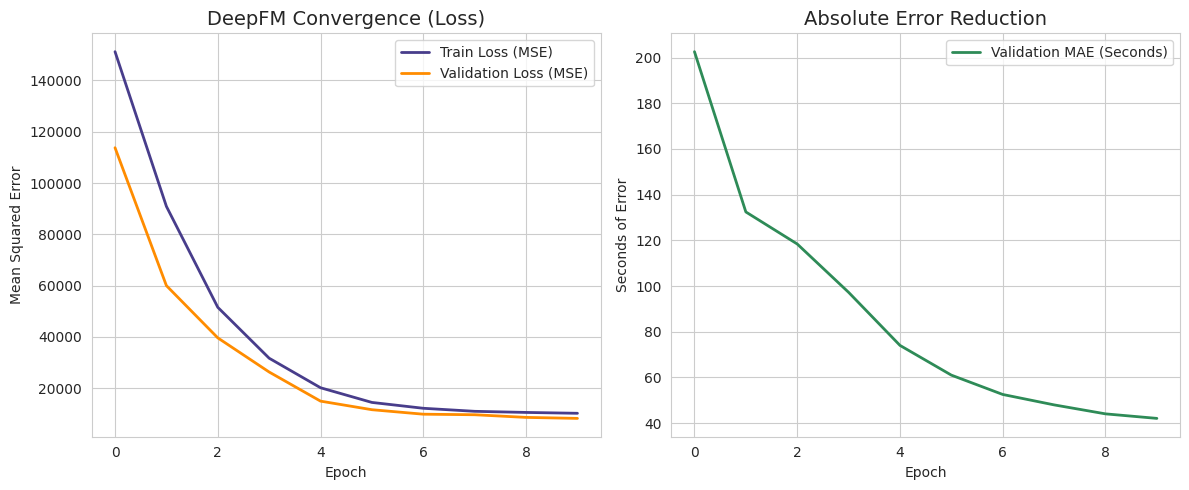

🏆 Final Validation MAE: 42.09 seconds


In [9]:
# ==========================================
# 7. VISUALIZE MODEL CONVERGENCE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

# Plot 1: RMSE (Training vs Validation)
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss (MSE)', color='darkslateblue', linewidth=2)
plt.plot(val_losses, label='Validation Loss (MSE)', color='darkorange', linewidth=2)
plt.title('DeepFM Convergence (Loss)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()

# Plot 2: MAE (Interpretability)
plt.subplot(1, 2, 2)
plt.plot(val_maes, label='Validation MAE (Seconds)', color='seagreen', linewidth=2)
plt.title('Absolute Error Reduction', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Seconds of Error')
plt.legend()

plt.tight_layout()
plt.show()

print(f"🏆 Final Validation MAE: {val_maes[-1]:.2f} seconds")

In [10]:
# ==========================================
# 8. EXPORT THE TRAINED MODEL
# ==========================================
import torch

# Define the save path
model_save_path = 'lamigo_deepfm_weights.pth'

# Save the state dictionary (the learned weights and biases)
torch.save(model.state_dict(), model_save_path)

print(f"💾 SUCCESS: Model weights saved locally to Colab as '{model_save_path}'")
print("📥 IMPORTANT: Download this file to your Mac from the Colab file explorer!")

💾 SUCCESS: Model weights saved locally to Colab as 'lamigo_deepfm_weights.pth'
📥 IMPORTANT: Download this file to your Mac from the Colab file explorer!


# Phase 5: Comprehensive Model Evaluation and Residual Analysis

## 1. Evaluation Methodology
To scientifically validate the predictive capabilities of the DeepFM architecture, we evaluate the model against both the Training and Testing datasets using three primary metrics:
1. **Mean Absolute Error (MAE):** Provides operational interpretability (average seconds of error).
2. **Root Mean Squared Error (RMSE):** Penalizes extreme prediction outliers, ensuring the model is reliable for edge-case logistics.
3. **Coefficient of Determination ($R^2$):** Measures the proportion of variance in delivery delays that the model's features successfully explain.

By comparing the Train and Test metrics side-by-side, we can empirically prove that the model generalized the underlying physical realities of Sri Lankan logistics rather than overfitting to specific IDs.

In [11]:
# ==========================================
# 10. COMPREHENSIVE METRIC EVALUATION
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_loader(loader, model_to_eval):
    model_to_eval.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_sparse, x_dense, y_target in loader:
            x_sparse, x_dense = x_sparse.to(device), x_dense.to(device)
            preds = model_to_eval(x_sparse, x_dense)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_target.numpy())

    # Calculate Metrics
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)

    return mae, rmse, r2, np.array(all_targets), np.array(all_preds)

print("🔍 Evaluating Training Set (Historical Memory)...")
train_mae, train_rmse, train_r2, train_actuals, train_preds = evaluate_loader(train_loader, model)

print("🔍 Evaluating Testing Set (Unseen Generalization)...")
test_mae, test_rmse, test_r2, test_actuals, test_preds = evaluate_loader(test_loader, model)

# Print beautifully formatted results for the thesis table
print("\n" + "="*50)
print("🏆 DEEPFM EVALUATION RESULTS")
print("="*50)
print(f"Metric\t\t| Training Set\t| Testing Set")
print("-" * 50)
print(f"R-Squared (R²)\t| {train_r2:.4f}\t| {test_r2:.4f}")
print(f"RMSE (Seconds)\t| {train_rmse:.2f} s\t| {test_rmse:.2f} s")
print(f"MAE (Seconds)\t| {train_mae:.2f} s\t| {test_mae:.2f} s")
print("="*50)

🔍 Evaluating Training Set (Historical Memory)...
🔍 Evaluating Testing Set (Unseen Generalization)...

🏆 DEEPFM EVALUATION RESULTS
Metric		| Training Set	| Testing Set
--------------------------------------------------
R-Squared (R²)	| 0.9190	| 0.9020
RMSE (Seconds)	| 83.46 s	| 90.58 s
MAE (Seconds)	| 40.84 s	| 42.09 s


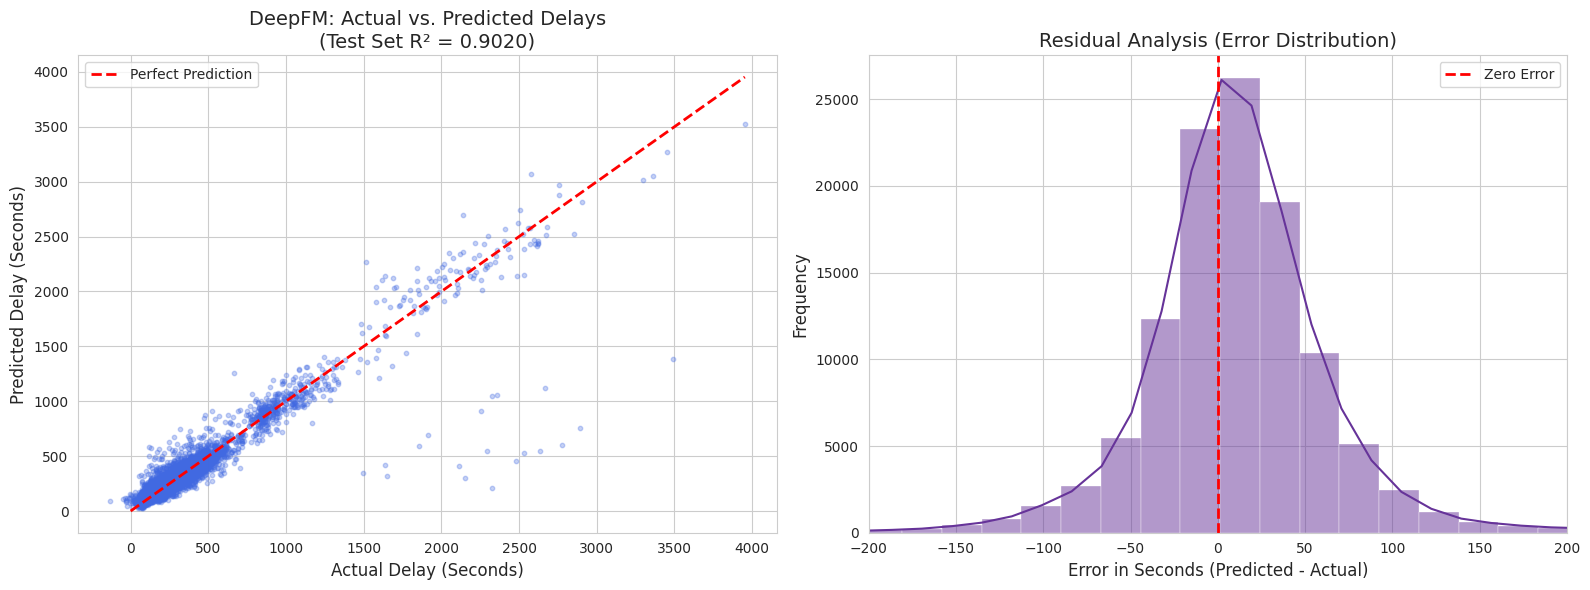

📊 Mean Residual Error (Systematic Bias): 8.83 seconds


In [12]:
# ==========================================
# 11. VISUALIZE PREDICTIONS VS REALITY
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: Actual vs Predicted (Testing Set) ----
# We sample 10,000 points so the scatter plot doesn't become a solid black block
sample_idx = np.random.choice(len(test_actuals), size=10000, replace=False)

axes[0].scatter(test_actuals[sample_idx], test_preds[sample_idx], alpha=0.3, color='royalblue', s=10)
# Draw the "Perfect Prediction" diagonal line
max_val = max(max(test_actuals[sample_idx]), max(test_preds[sample_idx]))
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')

axes[0].set_title(f'DeepFM: Actual vs. Predicted Delays\n(Test Set R² = {test_r2:.4f})', fontsize=14)
axes[0].set_xlabel('Actual Delay (Seconds)', fontsize=12)
axes[0].set_ylabel('Predicted Delay (Seconds)', fontsize=12)
axes[0].legend()

# ---- Plot 2: Residual Error Distribution ----
errors = test_preds - test_actuals

sns.histplot(errors, bins=150, kde=True, color='rebeccapurple', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')

axes[1].set_title('Residual Analysis (Error Distribution)', fontsize=14)
axes[1].set_xlabel('Error in Seconds (Predicted - Actual)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(-200, 200) # Zoom into the bulk of the data
axes[1].legend()

plt.tight_layout()
plt.show()

# Quick bias check
print(f"📊 Mean Residual Error (Systematic Bias): {np.mean(errors):.2f} seconds")

# Phase 6: The Inference Engine ("What-If" Analysis)

## 1. Objective: Proving Physical Interpretability
While aggregate metrics like MAE and $R^2$ prove statistical validity, they do not prove logical soundness. In this final phase, we construct an Inference Engine to test the model's understanding of logistics physics.

By taking a baseline delivery and artificially manipulating specific variables (e.g., `location_type`, `is_pin_verified`, `weather_code`), we can observe the model's localized predictions. If the architecture is physically sound, we should see mathematical penalties applied exactly where our empirical EDA phase suggested they would be (e.g., an unverified pin at an apartment during the rain should yield a massive compounding delay).

In [13]:
# ==========================================
# 12. BUILD THE INFERENCE PREDICTOR
# ==========================================
import joblib
import warnings
warnings.filterwarnings('ignore') # Suppress scikit-learn version warnings

def predict_delivery_delay(scenario_dict):
    """
    Takes a raw dictionary representing a delivery, applies the saved
    Silver-to-Gold transformations, and returns the model's predicted delay.
    """
    # 1. Convert the single scenario into a DataFrame
    df_inf = pd.DataFrame([scenario_dict])

    # 2. Transform Sparse Features (Load saved LabelEncoders)
    # Note: The models/metadata folder must be present!
    for col in sparse_features:
        le = joblib.load(f'models/metadata/le_{col}.joblib')

        # Ensure data types match the training phase
        if df_inf[col].dtype == 'object' or df_inf[col].dtype.name == 'category':
            df_inf[col] = df_inf[col].astype(str)
        else:
            df_inf[col] = df_inf[col].astype(int)

        # Handle unseen IDs gracefully by mapping them to a known baseline (0)
        # This simulates the "Cold Start" fallback we built earlier
        try:
            df_inf[col] = le.transform(df_inf[col])
        except ValueError:
            df_inf[col] = 0

    # 3. Transform Dense Features (Load saved StandardScaler)
    scaler = joblib.load('models/metadata/dense_scaler.joblib')
    df_inf[dense_features] = scaler.transform(df_inf[dense_features])

    # 4. Convert to PyTorch Tensors
    x_sparse = torch.tensor(df_inf[sparse_features].values, dtype=torch.long).to(device)
    x_dense = torch.tensor(df_inf[dense_features].values, dtype=torch.float32).to(device)

    # 5. Predict using the DeepFM Model
    model.eval()
    with torch.no_grad():
        predicted_delay = model(x_sparse, x_dense).item()

    return predicted_delay

print("✅ Inference Engine loaded and ready for What-If Analysis.")

✅ Inference Engine loaded and ready for What-If Analysis.


In [14]:
# ==========================================
# 13. EXECUTE WHAT-IF SCENARIOS
# ==========================================

# Let's create a perfectly normal, easy delivery as our Baseline
baseline_delivery = {
    # Categorical IDs
    'driver_id': 'D_001',
    'prev_customer_id': 'C_092',
    'customer_id': 'C_189',
    'destination_grid_id': '88611cb159fffff',
    'origin_grid_id': '88611cb333fffff',
    'vehicle_type_id': 'MOTORCYCLE',

    # The variables we will test:
    'location_type': 'HOME',           # Easy location
    'is_pin_verified': 'True',         # Easy to find
    'weather_code': '500',             # Clear weather
    'prev_cod_amount': 0.0,            # No cash handling friction

    # Context
    'prev_location_type': 'HOME',
    'month_of_year': '1',
    'day_of_week': '2',
    'hour_of_day': '10',               # Normal hour (No traffic)
    'prev_cod_friction_code': '0',
    'trip_sequence_id': '5',
    'trip_progress_id': '5',

    # Dense Physics
    'google_eta_seconds': 300.0,       # 5 minute drive
    'google_distance_meters': 1500.0,  # 1.5 km
    'rain_volume_1h': 0.0,             # Dry
    'trip_sequence_num': 5.0,
    'trip_progress_ratio': 0.50
}

print("🔬 RUNNING WHAT-IF SCENARIOS...")
print("-" * 50)

# Scenario 1: The Baseline
delay_baseline = predict_delivery_delay(baseline_delivery)
print(f"Scenario 1: Baseline (Home, Clear Weather, Verified Pin)")
print(f"👉 Predicted Delay: {delay_baseline:.1f} seconds")
print("-" * 50)

# Scenario 2: Change Home to Apartment (Vertical Friction)
test_2 = baseline_delivery.copy()
test_2['location_type'] = 'APARTMENT'
delay_2 = predict_delivery_delay(test_2)
print(f"Scenario 2: Changed 'HOME' to 'APARTMENT'")
print(f"👉 Predicted Delay: {delay_2:.1f} seconds (+{delay_2 - delay_baseline:.1f}s penalty)")
print("-" * 50)

# Scenario 3: Unverified Pin at the Apartment (Search Friction)
test_3 = test_2.copy()
test_3['is_pin_verified'] = 'False'
delay_3 = predict_delivery_delay(test_3)
print(f"Scenario 3: Unverified Pin at the Apartment")
print(f"👉 Predicted Delay: {delay_3:.1f} seconds (+{delay_3 - delay_2:.1f}s penalty)")
print("-" * 50)

# Scenario 4: The Perfect Storm (Apartment + Unverified Pin + Heavy Rain)
test_4 = test_3.copy()
test_4['weather_code'] = '200' # Thunderstorm
test_4['rain_volume_1h'] = 5.5 # Heavy Rain
delay_4 = predict_delivery_delay(test_4)
print(f"Scenario 4: The Perfect Storm (Heavy Rain added)")
print(f"👉 Predicted Delay: {delay_4:.1f} seconds (+{delay_4 - delay_3:.1f}s penalty)")
print("=" * 50)

🔬 RUNNING WHAT-IF SCENARIOS...
--------------------------------------------------
Scenario 1: Baseline (Home, Clear Weather, Verified Pin)
👉 Predicted Delay: 253.4 seconds
--------------------------------------------------
Scenario 2: Changed 'HOME' to 'APARTMENT'
👉 Predicted Delay: 396.6 seconds (+143.2s penalty)
--------------------------------------------------
Scenario 3: Unverified Pin at the Apartment
👉 Predicted Delay: 884.3 seconds (+487.7s penalty)
--------------------------------------------------
Scenario 4: The Perfect Storm (Heavy Rain added)
👉 Predicted Delay: 925.9 seconds (+41.7s penalty)
